# Data Processing for UNSW Gear Crack Dataset

**V1:**

-   Proven results
-   Only Nico's data (on top of base raw measurements)
-   Step size 5

**V2:**

-   Include both Nico's and Yaxin's data (on top of base raw measurements).
-   Step size 2


In [ ]:
from pathlib import Path

import numpy as np
import pandas as pd
import plotly.express as px
import scipy
from matplotlib import pyplot as plt
from preprocessing_individual import get_important_frequencies
from signal_analysis import FFT_TSA, order_track_FFT, order_track_signal, signal_TSA

In [ ]:
include_Nicos = True  # Measurements already order tracked by Nico with Pietro's code
include_Yaxins = True  # Experiments by Yaxin (wear / no lubrication)

data_folder = Path.cwd().parent.parent.parent / "data" / "UNSW_gear_crack"  # YYY
# data_folder = Path.cwd().parent.parent.parent / "data" / "UNSW_gear_crack_Nico_OT" # XXX
files = data_folder.glob("*.mat")

revolutions_per_TSA = 40  # 36 teeth in the faulty gear
step_size = 2

measurements = []
for f in files:
    # Get measurement specs
    fname_parts = f.stem.split("_")

    speed = int(fname_parts[1][:2])
    load = int(fname_parts[2][:2])
    severity = fname_parts[3]

    print(f)

    # NICO'S OT CONVERSION
    ##

    if include_Nicos:
        # Get signal
        nico_f = Path(
            str(f)
            .replace("UNSW_gear_crack", "UNSW_gear_crack_Nico_OT")
            .replace("Data_", "OT_Data_")
        )

        if nico_f.exists():
            mat = scipy.io.loadmat(nico_f)
            signal_OT = mat["signal_order_track"][0]
            # Get average torque
            torqueAvg = mat["torqueAvg"][0][0]

            signal_OT_TSA = signal_TSA(signal_OT, 2700, revolutions_per_TSA, step_size)
            samples = np.abs(np.fft.rfft(signal_OT_TSA, norm="forward", axis=1))[
                :, : 11 * 27
            ]  # 10 first full GMFs and the DC component

            # Convert to float32, as that is what Pytorch expects
            samples = samples.astype(np.float32)
            print("Nico", samples.shape)

            for j in range(len(samples)):
                measurements.append([
                    speed,
                    load,
                    severity,
                    # torqueAvg,
                    "nico",
                    revolutions_per_TSA,
                    samples[j],
                ])
        else:
            print(f"{nico_f} does not exist in Nico's data, skipping...")

    # MY OT CONVERSIONS
    ##

    non_OT_mat = scipy.io.loadmat(f)

    # Normal
    try:
        signal = non_OT_mat["signals"][:, 4]  # acceleration
        enc_signal = non_OT_mat["signals"][:, 1]  # Input shaft encoder
    # Yaxin's
    except KeyError:
        if not include_Yaxins:
            print(f"{f} is Yaxin's data, skipping...")
            continue
        signal = non_OT_mat["data"][0][7][:, 0] * 100
        enc_signal = non_OT_mat["data"][0][3][:, 0]  # Input shaft encoder

    crossing_idxs = np.where(np.logical_and(enc_signal[:-1] <= 0, enc_signal[1:] > 0))[
        0
    ]
    crossings_angles = np.arange(len(crossing_idxs)) * (360 / 3600)
    enc_angle = np.interp(np.arange(len(enc_signal)), crossing_idxs, crossings_angles)

    # ? Probably should do anti-aliasing, but doesn't seem to affect much
    # sos = butter(4, 2000, btype="lowpass", output="sos", fs=200000)
    # signal = sosfiltfilt(sos, signal)

    # SIGNAL OT
    ##

    signal_OT = order_track_signal(
        signal,
        np.arange(len(signal)) / 200000,  # 200000 = sampling frequency
        enc_angle,
        num_samples_per_revolution=2700,
    )

    signal_OT_TSA = signal_TSA(signal_OT, 2700, revolutions_per_TSA, step_size)
    samples = np.abs(np.fft.rfft(signal_OT_TSA, norm="forward", axis=1))[
        :, : 11 * 27
    ]  # 10 first full GMFs and the DC component

    # Convert to float32, as that is what Pytorch expects
    samples = samples.astype(np.float32)

    print("Signal", samples.shape)
    for j in range(len(samples)):  # Continue from the last index
        measurements.append([
            speed,
            load,
            severity,
            # torqueAvg,
            "signal",
            revolutions_per_TSA,
            samples[j],
        ])

    # FFT OT
    ##

    revolution_FFTs = order_track_FFT(
        signal,
        np.arange(len(signal)) / 200000,
        enc_angle,
        num_orders=11 * 27,
    )
    samples = FFT_TSA(revolution_FFTs, revolutions_per_TSA, step_size)
    samples = np.array(samples, dtype=np.float32)

    print("FFT", samples.shape)
    for j in range(len(samples)):  # Continue from the last index
        measurements.append([
            speed,
            load,
            severity,
            # torqueAvg,
            "fft",
            revolutions_per_TSA,
            samples[j],
        ])

df_OT_TSA_FFT_expanded = pd.DataFrame(
    data=measurements,
    columns=[
        "speed",
        "load",
        "severity",
        # "torqueAvg",
        "OT_method",
        "TSA_size",
        "signal",
    ],
)

print(len(df_OT_TSA_FFT_expanded))
df_OT_TSA_FFT_expanded.head(2)

/Users/hamalaa14/git/data/UNSW_gear_crack/Data_05Hz_20Nm_S.mat
Nico (32, 297)
Signal (32, 297)
FFT (31, 297)
/Users/hamalaa14/git/data/UNSW_gear_crack/Data_02Hz_20Nm_S.mat
Nico (40, 297)
Signal (40, 297)
FFT (39, 297)
/Users/hamalaa14/git/data/UNSW_gear_crack/Data_10Hz_20Nm_S.mat
Nico (84, 297)
Signal (84, 297)
FFT (84, 297)
/Users/hamalaa14/git/data/UNSW_gear_crack/Data_15Hz_20Nm_H.mat
Nico (136, 297)
Signal (137, 297)
FFT (136, 297)
/Users/hamalaa14/git/data/UNSW_gear_crack/Data_10Hz_05Nm_H4.mat
/Users/hamalaa14/git/data/UNSW_gear_crack_Nico_OT/OT_Data_10Hz_05Nm_H4.mat does not exist in Nico's data, skipping...
Signal (135, 297)
FFT (134, 297)
/Users/hamalaa14/git/data/UNSW_gear_crack/Data_15Hz_20Nm_L.mat
Nico (136, 297)
Signal (137, 297)
FFT (136, 297)
/Users/hamalaa14/git/data/UNSW_gear_crack/Data_15Hz_20Nm_M.mat
Nico (136, 297)
Signal (137, 297)
FFT (136, 297)
/Users/hamalaa14/git/data/UNSW_gear_crack/Data_10Hz_05Nm_H3.mat
/Users/hamalaa14/git/data/UNSW_gear_crack_Nico_OT/OT_Data_

,speed,load,severity,OT_method,TSA_size,signal
0,5,20,S,nico,40,"[0.016037561, 0.001796368, 0.0015128184, 0.001..."
1,5,20,S,nico,40,"[0.015598994, 0.0015774206, 0.0019360062, 0.00..."


In [13]:
pd.options.display.max_rows = 120
df_OT_TSA_FFT_expanded.groupby(["speed", "load", "severity"]).count()

OT_method  TSA_size  signal
speed load severity                             
2     0    H               121       121     121
           L               122       122     122
           M               122       122     122
           S               121       121     121
      5    H               121       121     121
           H3               21        21      21
           H4              190       190     190
           H5               21        21      21
           L               121       121     121
           M               121       121     121
           S               121       121     121
           W1               21        21      21
           W2               21        21      21
           W3               21        21      21
           W4               21        21      21
           W5               20        20      20
           W6               21        21      21
      10   H               120       120     120
           L               120       120     120
           M               120       120     120
           S               120       120     120
      15   H               120       120     120
           L               119       119     119
           M               120       120     120
           S               120       120     120
      20   H               119       119     119
           L               118       118     118
           M               118       118     118
           S               119       119     119
5     0    H                97        97      97
           L                96        96      96
           M                96        96      96
           S                97        97      97
      5    H                96        96      96
           L                96        96      96
           M                96        96      96
           S                96        96      96
      10   H                96        96      96
           L                96        96      96
           M                96        96      96
           S                96        96      96
      15   H                95        95      95
           L                95        95      95
           M                95        95      95
           S                96        96      96
      20   H                94        94      94
           L                95        95      95
           M                94        94      94
           S                95        95      95
10    0    H               255       255     255
           L               254       254     254
           M               254       254     254
           S               255       255     255
      5    H               254       254     254
           H3              269       269     269
           H4              269       269     269
           L               253       253     253
           M               254       254     254
           S               254       254     254
           W1              269       269     269
           W2              269       269     269
           W3              269       269     269
           W4              269       269     269
           W5              269       269     269
           W6              269       269     269
      10   H               254       254     254
           L               254       254     254
           M               253       253     253
           S               254       254     254
      15   H               252       252     252
           L               252       252     252
           M               252       252     252
           S               253       253     253
      20   H               252       252     252
           L               252       252     252
           M               252       252     252
           S               252       252     252
15    0    H               412       412     412
           L               412       412     412
           M               413       413     413
   

In [ ]:
df_OT_TSA_FFT_expanded.to_feather(
    Path.cwd().parent.parent / "data" / "UNSW_gear_crack_OT_V2.feather"
    # / "UNSW_gear_crack_OT.feather"
    # Path.cwd().parent.parent / "data" / "UNSW_gear_crack_OT_TSA_15.feather"
)

In [14]:
df_OT_TSA_FFT_expanded

,speed,load,severity,OT_method,TSA_size,signal
0,5,20,S,signal,40,"[0.009778606, 0.000587674, 0.00089263084, 0.00..."
1,5,20,S,signal,40,"[0.010351999, 0.00072535546, 0.0008116836, 0.0..."
2,5,20,S,signal,40,"[0.010522721, 0.00072592305, 0.00084416696, 0...."
3,5,20,S,signal,40,"[0.010454714, 0.0015159218, 0.0010542646, 0.00..."
4,5,20,S,signal,40,"[0.01028244, 0.0013983808, 0.00096541113, 0.00..."
...,...,...,...,...,...,...
8774,10,20,H,fft,40,"[0.0048896843, 0.001296983, 0.0013203243, 0.00..."
8775,10,20,H,fft,40,"[0.0042326013, 0.0013206223, 0.0012952524, 0.0..."
8776,10,20,H,fft,40,"[0.003785193, 0.0013438636, 0.0012228125, 0.00..."
8777,10,20,H,fft,40,"[0.0030207043, 0.0014279177, 0.0013486267, 0.0..."


## Testing


In [15]:
df_testing = pd.read_feather(
    Path.cwd().parent.parent / "data" / "UNSW_gear_crack_OT_TMP.feather"
)
df_testing

,speed,load,severity,OT_method,TSA_size,signal
0,5,20,S,signal,40,"[0.009778606, 0.000587674, 0.00089263084, 0.00..."
1,5,20,S,signal,40,"[0.010351999, 0.00072535546, 0.0008116836, 0.0..."
2,5,20,S,signal,40,"[0.010522721, 0.00072592305, 0.00084416696, 0...."
3,5,20,S,signal,40,"[0.010454714, 0.0015159218, 0.0010542646, 0.00..."
4,5,20,S,signal,40,"[0.01028244, 0.0013983808, 0.00096541113, 0.00..."
...,...,...,...,...,...,...
8774,10,20,H,fft,40,"[0.0048896843, 0.001296983, 0.0013203243, 0.00..."
8775,10,20,H,fft,40,"[0.0042326013, 0.0013206223, 0.0012952524, 0.0..."
8776,10,20,H,fft,40,"[0.003785193, 0.0013438636, 0.0012228125, 0.00..."
8777,10,20,H,fft,40,"[0.0030207043, 0.0014279177, 0.0013486267, 0.0..."


In [ ]:
# df_testing[(df_testing["speed"] == 20) & (df_testing["load"] == 5) & (df_testing["severity"] == "M") & (df_testing["OT_method"] == "signal")]

,speed,load,severity,OT_method,TSA_size,signal
6762,20,5,M,signal,40,"[0.0034790405, 0.0060053733, 0.001508202, 0.00..."
6763,20,5,M,signal,40,"[0.0033349579, 0.0062394463, 0.0022357893, 0.0..."
6764,20,5,M,signal,40,"[0.003701688, 0.006543554, 0.002635331, 0.0023..."
6765,20,5,M,signal,40,"[0.0039313626, 0.006411104, 0.002835439, 0.002..."
6766,20,5,M,signal,40,"[0.0045350767, 0.0063180644, 0.0030155855, 0.0..."
6767,20,5,M,signal,40,"[0.004899959, 0.006201298, 0.0030191846, 0.002..."
6768,20,5,M,signal,40,"[0.005240596, 0.006107227, 0.0026647516, 0.002..."
6769,20,5,M,signal,40,"[0.0059535634, 0.006226667, 0.0022395826, 0.00..."
6770,20,5,M,signal,40,"[0.006657609, 0.006056308, 0.002033315, 0.0021..."
6771,20,5,M,signal,40,"[0.006940402, 0.006049037, 0.0013428645, 0.001..."


In [7]:
df_testing = df_testing[df_testing["OT_method"] == "signal"]
df_testing = df_testing[(df_testing["load"] == 5) & (df_testing["speed"].isin([2, 10]))]
df_testing

,speed,load,severity,OT_method,TSA_size,signal
236,10,5,H4,signal,40,"[0.0060712025, 0.0016340358, 0.001597253, 0.00..."
237,10,5,H4,signal,40,"[0.0057692556, 0.0014596896, 0.0012545236, 0.0..."
238,10,5,H4,signal,40,"[0.0070193713, 0.0011384715, 0.0013459026, 0.0..."
239,10,5,H4,signal,40,"[0.008394858, 0.0009827486, 0.0012393035, 0.00..."
240,10,5,H4,signal,40,"[0.008674744, 0.0004813951, 0.0009888959, 0.00..."
...,...,...,...,...,...,...
8516,2,5,H4,signal,40,"[0.010070492, 0.0009524432, 0.001360462, 0.000..."
8517,2,5,H4,signal,40,"[0.0104519185, 0.00096501986, 0.0013976856, 0...."
8518,2,5,H4,signal,40,"[0.010182654, 0.0006819447, 0.0012192972, 0.00..."
8519,2,5,H4,signal,40,"[0.010265975, 0.00046110956, 0.0007810437, 0.0..."


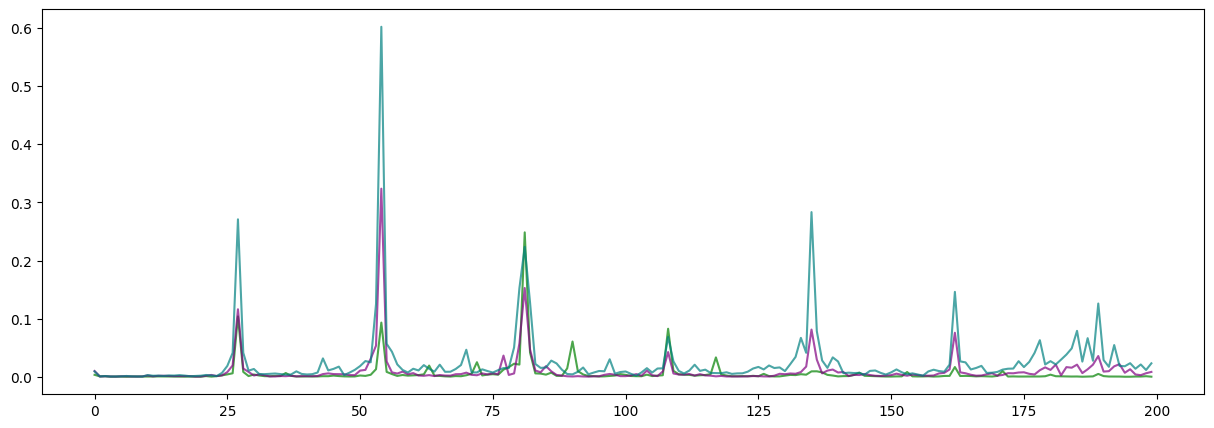

In [8]:
healthy_1 = np.mean(df_testing[df_testing["severity"] == "H"]["signal"], axis=0)
healthy_2 = np.mean(df_testing[df_testing["severity"] == "S"]["signal"], axis=0)
healthy_3 = np.mean(df_testing[df_testing["severity"] == "H3"]["signal"], axis=0)
healthy_4 = np.mean(df_testing[df_testing["severity"] == "H4"]["signal"], axis=0)
faulty_M = np.mean(df_testing[df_testing["severity"] == "M"]["signal"], axis=0)
faulty_L = np.mean(df_testing[df_testing["severity"] == "L"]["signal"], axis=0)
# healthy_1 = df_testing[df_testing["severity"] == "H"]["signal"].iloc[0]
# healthy_2 = df_testing[df_testing["severity"] == "S"]["signal"].iloc[0]
# faulty_M =  df_testing[df_testing["severity"] == "M"]["signal"].iloc[0]
# faulty_L =  df_testing[df_testing["severity"] == "L"]["signal"].iloc[0]

plt.subplots(figsize=(15, 5))
plt.plot(healthy_1[:200], color="green", label="Healthy 1", alpha=0.7)
# plt.plot(healthy_2[:200], color="blue", label="Healthy 2", alpha=0.7)
plt.plot(healthy_3[:200], color="purple", label="Healthy 3", alpha=0.7)
plt.plot(healthy_4[:200], color="teal", label="Healthy 4", alpha=0.7)
# plt.plot(faulty_M[:200], color="orange", label="Faulty M", alpha=0.7)
# plt.plot(faulty_L[:200], color="red", label="Faulty L", alpha=0.7)

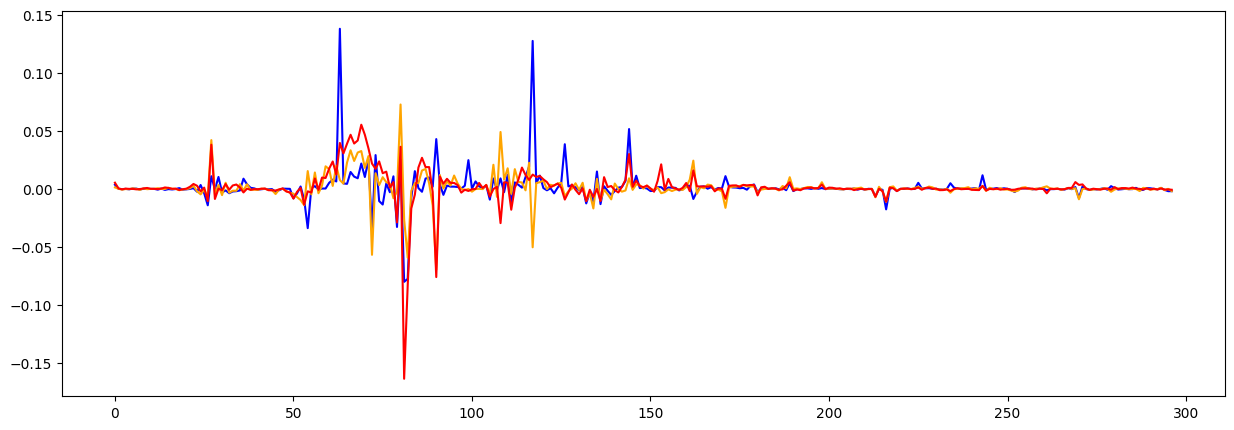

In [8]:
plt.subplots(figsize=(15, 5))
plt.plot(healthy_2 - healthy_1, color="b")
plt.plot(faulty_M - healthy_1, color="orange")
plt.plot(faulty_L - healthy_1, color="r")

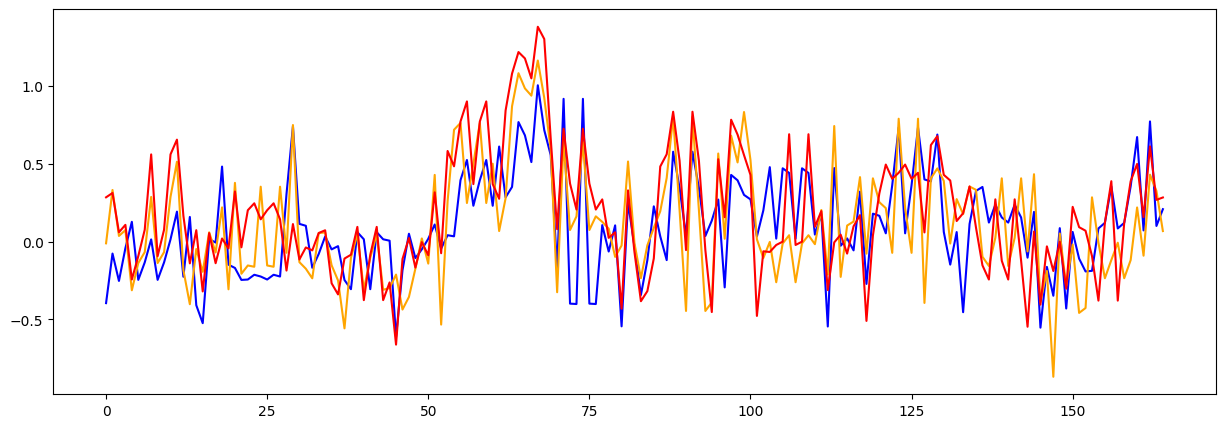

In [9]:
plt.subplots(figsize=(15, 5))
plt.plot(
    np.log10(healthy_2[get_important_frequencies(27, 5, 8)])
    - np.log10(healthy_1[get_important_frequencies(27, 5, 8)]),
    color="b",
)
plt.plot(
    np.log10(faulty_M[get_important_frequencies(27, 5, 8)])
    - np.log10(healthy_1[get_important_frequencies(27, 5, 8)]),
    color="orange",
)
plt.plot(
    np.log10(faulty_L[get_important_frequencies(27, 5, 8)])
    - np.log10(healthy_1[get_important_frequencies(27, 5, 8)]),
    color="r",
)

### Cepstrum


In [14]:
px.line(df_testing.iloc[0]["signal"])

In [8]:
px.line(np.log10(df_testing.iloc[0]["signal"]))

In [22]:
asd = np.fft.ifft(np.log(df_testing.iloc[0]["signal"])).real
px.line(asd[1:])

In [50]:
spectrum_healthy = df_testing[
    (df_testing["severity"] == "H")
    & (df_testing["load"] == 20)
    & (df_testing["speed"] == 20)
    & (df_testing["OT_method"] == "signal")
].iloc[0]["signal"]

spectrum_healthy2 = df_testing[
    (df_testing["severity"] == "S")
    & (df_testing["load"] == 20)
    & (df_testing["speed"] == 20)
    & (df_testing["OT_method"] == "signal")
].iloc[-1]["signal"]

spectrum = df_testing[
    (df_testing["severity"] == "L")
    & (df_testing["load"] == 20)
    & (df_testing["speed"] == 20)
    & (df_testing["OT_method"] == "signal")
].iloc[0]["signal"]

px.line(spectrum_healthy)

In [51]:
px.line(spectrum)

In [52]:
ceps = np.fft.ifft(np.log10(spectrum)).real
ceps_healthy = np.fft.ifft(np.log10(spectrum_healthy)).real
ceps_healthy2 = np.fft.ifft(np.log10(spectrum_healthy2)).real

px.line(ceps_healthy[1:])

In [53]:
px.line(ceps_healthy2[1:])

In [54]:
px.line(ceps[1:])

In [55]:
px.line(ceps[1:] - ceps_healthy[1:])

In [56]:
px.line(ceps_healthy2[1:] - ceps_healthy[1:])